# Kapitel 7: Fat-Tail-Erweiterung auf Tagesdaten

**Benötigte Pakete:** `numpy`, `pandas`, `matplotlib`, `scipy`, `cvxpy`
(mit Solver `ECOS`).

**Ausführung:** Die CSV-Datei ins Arbeitsverzeichnis legen (oder `CSV_PATH`
in Abschnitt 1 anpassen) und die Zellen der Reihe nach ausführen.

**Notation (Code = Arbeit):** `epsilon` $=\epsilon$ (Konfidenzniveau),
`pi_0` $=\pi_0$ (Nominalverteilung), `pi_experts` $=\pi^i$
(Phasen-Verteilungen), `eta_lower`/`eta_upper` $=\eta,\bar\eta$
(Box-Grenzen als nicht-negative Beträge; die vorzeichenbehaftete Untergrenze
von $\eta$ ist $-\eta$).

## 1. Daten laden

Einlesen des Tagesdaten-Blocks der Kenneth-French-CSV und Filterung auf den
Krisenzeitraum. 

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cvxpy as cp

def load_30_industry_portfolios_daily(csv_path, start="20070701", end="20091231"):
    """
    Liest den ersten Tabellenblock ("Average Value Weighted Returns -- Daily")
    aus der Kenneth-French CSV und filtert auf [start, end] (Format YYYYMMDD).
    """
    with open(csv_path, "r") as f:
        lines = f.readlines()

    header_idx = next(i for i, l in enumerate(lines) if "Average Value Weighted Returns -- Daily" in l)
    colnames_idx = header_idx + 1
    while lines[colnames_idx].strip() == "":
        colnames_idx += 1
    colnames = [c.strip() for c in lines[colnames_idx].strip().split(",")]
    colnames[0] = "date"

    data_rows = []
    i = colnames_idx + 1
    while i < len(lines) and lines[i].strip() != "":
        row = [v.strip() for v in lines[i].strip().split(",")]
        data_rows.append(row)
        i += 1

    df = pd.DataFrame(data_rows, columns=colnames)
    df["date"] = df["date"].astype(int)
    for c in colnames[1:]:
        df[c] = df[c].astype(float)
    df = df.set_index("date")
    df = df.loc[(df.index >= int(start)) & (df.index <= int(end))]
    df = df.replace([-99.99, -999], np.nan)
    return df

# Pfad zur Kenneth-French-CSV (Datei ins Arbeitsverzeichnis legen oder Pfad anpassen)
CSV_PATH = "30_Industry_Portfolios_Daily.csv"

# Krisenzeitraum 2007-2009 (Standardfenster der Analyse)
df_daily = load_30_industry_portfolios_daily(CSV_PATH)
print("Shape:", df_daily.shape)
print("Zeitraum:", df_daily.index.min(), "-", df_daily.index.max())
df_daily.head()

Shape: (632, 30)
Zeitraum: 20070702 - 20091231


,Food,Beer,Smoke,Games,Books,Hshld,Clths,Hlth,Chems,Txtls,...,Telcm,Servs,BusEq,Paper,Trans,Whlsl,Rtail,Meals,Fin,Other
date,,,,,,,,,,,,,,,,,,,,,
20070702,1.04,0.54,0.96,0.40,0.62,0.81,0.40,0.88,1.66,0.88,...,1.42,0.60,1.06,1.21,0.95,0.94,0.66,0.79,1.19,0.42
20070703,-0.64,0.19,0.21,-0.38,-0.29,0.28,0.44,0.19,0.17,-0.03,...,0.21,0.52,0.78,0.11,0.75,0.11,-0.07,1.21,0.58,0.73
20070705,-0.39,0.14,0.35,2.12,0.62,-0.07,1.10,0.09,0.76,0.71,...,-0.22,0.51,0.57,0.42,-0.03,0.07,0.12,2.93,-0.49,0.00
20070706,0.17,0.01,0.57,0.53,0.10,0.07,1.16,-0.11,0.31,0.35,...,0.33,0.32,0.44,-0.01,0.51,0.03,1.24,0.33,0.37,0.11
20070709,0.64,-0.16,-0.17,0.22,-0.33,0.21,-0.32,-0.05,0.51,-1.03,...,-0.20,-0.10,0.19,-0.03,0.93,0.07,-0.32,-0.51,-0.36,0.29


## 2. Normalitätsprüfung (Jarque-Bera-Test)

Der Jarque-Bera-Test prüft die Normalverteilungsannahme je Asset. Der Vergleich
zwischen ruhiger Periode (2004-2006) und Krisenperiode (2007-2009) motiviert die
Fat-Tail-Betrachtung.

In [22]:
from scipy.stats import jarque_bera, skew, kurtosis

def jb_test_summary(returns_df, alpha=0.05):
    """
    Führt den Jarque-Bera-Test auf jede Spalte (Asset) eines Renditen-DataFrames aus.
    Analog zur Methodik von Huang et al. (2010), die den JB-Test zur Prüfung der
    Normalverteilungsannahme auf ihre Equity-Daten anwenden.
    """
    results = []
    for col in returns_df.columns:
        series = returns_df[col].dropna()
        stat, p_value = jarque_bera(series)
        results.append({
            "Asset": col,
            "Skewness": skew(series),
            "Kurtosis (Exzess)": kurtosis(series),  # kurtosis() liefert Exzess-Kurtosis (Normal = 0)
            "JB-Statistik": stat,
            "p-Wert": p_value,
            "H0 verworfen (5%)": p_value < alpha,
        })
    return pd.DataFrame(results).set_index("Asset")


jb_daily_crisis = jb_test_summary(df_daily)
print(f"Anteil Assets mit verworfener Normalverteilungsannahme (5%-Niveau): "
      f"{jb_daily_crisis['H0 verworfen (5%)'].mean():.1%}")
jb_daily_crisis.round(4)


Anteil Assets mit verworfener Normalverteilungsannahme (5%-Niveau): 100.0%


,Skewness,Kurtosis (Exzess),JB-Statistik,p-Wert,H0 verworfen (5%)
Asset,,,,,
Food,0.1560,5.8352,899.2144,0.0,True
Beer,0.5663,7.6538,1576.3896,0.0,True
Smoke,0.3358,8.9194,2106.8655,0.0,True
Games,0.0241,1.9178,96.9101,0.0,True
Books,0.1693,2.7175,197.4867,0.0,True
Hshld,0.0629,4.8452,618.6266,0.0,True
Clths,0.1592,2.3374,146.5351,0.0,True
Hlth,0.2612,8.1854,1771.5329,0.0,True
Chems,-0.2987,3.1591,272.1930,0.0,True


In [23]:
df_calm = load_30_industry_portfolios_daily(
    CSV_PATH, start="20040101", end="20061231"
)
print("Ruhige Periode Shape:", df_calm.shape)

jb_calm = jb_test_summary(df_calm)
print(f"Ruhige Periode (2004-2006): Anteil verworfen (5%): {jb_calm['H0 verworfen (5%)'].mean():.1%}")
print(f"Krisenperiode (2007-2009): Anteil verworfen (5%): {jb_daily_crisis['H0 verworfen (5%)'].mean():.1%}")
print()
print("Durchschnittliche Exzess-Kurtosis, ruhige Periode:", round(jb_calm["Kurtosis (Exzess)"].mean(), 3))
print("Durchschnittliche Exzess-Kurtosis, Krisenperiode:  ", round(jb_daily_crisis["Kurtosis (Exzess)"].mean(), 3))

Ruhige Periode Shape: (755, 30)
Ruhige Periode (2004-2006): Anteil verworfen (5%): 73.3%
Krisenperiode (2007-2009): Anteil verworfen (5%): 100.0%

Durchschnittliche Exzess-Kurtosis, ruhige Periode: 1.37
Durchschnittliche Exzess-Kurtosis, Krisenperiode:   4.304


## 3. Marktphasen und Box-Unsicherheitsmenge

Der Krisenzeitraum wird in drei Marktphasen unterteilt. Jede Phase liefert eine
Experten-Verteilung $\pi^i$; zusammen mit der gleichgewichteten Nominalverteilung
$\pi_0$ spannen sie die Box-Unsicherheitsmenge auf.

In [24]:
def split_by_date_ranges(returns_df, boundaries):
    """
    Teilt eine Zeitreihe anhand vorgegebener Datumsgrenzen (YYYYMMDD) in Phasen auf.
    boundaries: Liste von (name, start, end) Tupeln.
    """
    blocks = {}
    for name, start, end in boundaries:
        mask = (returns_df.index >= start) & (returns_df.index <= end)
        blocks[name] = returns_df.loc[mask]
    return blocks


boundaries = [
    ("Vorkrise",  20070702, 20080914),
    ("Crash",     20080915, 20090309),
    ("Erholung",  20090310, 20091231),
]

crisis_blocks = split_by_date_ranges(df_daily, boundaries)

for name, block in crisis_blocks.items():
    print(f"{name:<10}: {block.index.min()} - {block.index.max()}  ({len(block)} Handelstage)")

Vorkrise  : 20070702 - 20080912  (304 Handelstage)
Crash     : 20080915 - 20090309  (121 Handelstage)
Erholung  : 20090310 - 20091231  (207 Handelstage)


In [25]:
S = len(df_daily)  # Gesamtzahl Szenarien (Handelstage)
dates_all = df_daily.index.to_numpy()

# Nominalverteilung: alle S Tage gleichgewichtet (Standardannahme)
pi_0 = np.full(S, 1.0 / S)

# Experten-Verteilungen: je nur die Tage der eigenen Phase gleichgewichtet, Rest = 0
pi_experts = {}
for name, block in crisis_blocks.items():
    pi_i = np.zeros(S)
    mask = np.isin(dates_all, block.index.to_numpy())
    pi_i[mask] = 1.0 / mask.sum()
    pi_experts[name] = pi_i
    print(f"{name}: Summe = {pi_i.sum():.4f}, Anzahl Tage mit pi>0 = {(pi_i > 0).sum()}")

print(f"\nNominalverteilung pi_0: Summe = {pi_0.sum():.4f}")

Vorkrise: Summe = 1.0000, Anzahl Tage mit pi>0 = 304
Crash: Summe = 1.0000, Anzahl Tage mit pi>0 = 121
Erholung: Summe = 1.0000, Anzahl Tage mit pi>0 = 207

Nominalverteilung pi_0: Summe = 1.0000


In [26]:
pi_matrix = np.stack(list(pi_experts.values()))  # Shape (m=3, S)

eta_lower = np.max(pi_0[None, :] - pi_matrix, axis=0)
eta_lower = np.clip(eta_lower, 0, None)

eta_upper = np.max(pi_matrix - pi_0[None, :], axis=0)
eta_upper = np.clip(eta_upper, 0, None)

print("eta_lower (eta): Min/Max =", eta_lower.min(), "/", eta_lower.max())
print("eta_upper (eta_bar): Min/Max =", eta_upper.min(), "/", eta_upper.max())
print()
print("Anzahl Szenarien mit eta_lower > 0:", (eta_lower > 0).sum(), "von", S)
print("Anzahl Szenarien mit eta_upper > 0:", (eta_upper > 0).sum(), "von", S)

# Konsistenzcheck: jede Expertenverteilung muss innerhalb der Box liegen
for name, pi_i in pi_experts.items():
    innerhalb = np.all((pi_0 - eta_lower - 1e-10 <= pi_i) & (pi_i <= pi_0 + eta_upper + 1e-10))
    print(f"{name} liegt vollständig in der Box: {innerhalb}")

eta_lower (eta): Min/Max = 0.0015822784810126582 / 0.0015822784810126582
eta_upper (eta_bar): Min/Max = 0.001707195203197868 / 0.006682184328904698

Anzahl Szenarien mit eta_lower > 0: 632 von 632
Anzahl Szenarien mit eta_upper > 0: 632 von 632
Vorkrise liegt vollständig in der Box: True
Crash liegt vollständig in der Box: True
Erholung liegt vollständig in der Box: True


In [27]:
R = df_daily.to_numpy()  # Shape (S, n)  Renditematrix, Zeilen=Tage, Spalten=Assets
n = R.shape[1]

# Sinnvoller Zielrenditebereich für TÄGLICHE Renditen (viel kleiner als bei Monatsdaten!)
mean_returns_daily = R.T @ pi_0  # gewichteter Mittelwert je Asset unter pi_0
print("Durchschnittliche tägliche Rendite je Asset (Bereich):", 
      round(mean_returns_daily.min(), 4), "bis", round(mean_returns_daily.max(), 4))

Durchschnittliche tägliche Rendite je Asset (Bereich): -0.0803 bis 0.139


## 4. Optimierungsmodelle

Alle Modelle sind als lineare Programme (LP) nach Rockafellar/Uryasev formuliert
und werden mit `cvxpy`/`ECOS` gelöst.

### 4.1 Nominales CVaR (LP)

In [28]:
def solve_nominal_cvar_lp(R, pi, target_mu, epsilon=0.95, w0=1.0, x_lower=0.0, x_upper=1.0):
    """
    Nominales CVaR-Portfolio als LP (Rockafellar-Uryasev)
    mit eta=eta_bar=0 (Spezialfall ohne Box-Unsicherheit).
    R: (S,n) Renditematrix, pi: (S,) Wahrscheinlichkeitsvektor.
    """
    S, n = R.shape
    x = cp.Variable(n)
    gamma = cp.Variable()
    u = cp.Variable(S)

    objective = cp.Minimize(gamma + (1 / (1 - epsilon)) * (pi @ u))
    constraints = [
        cp.sum(x) == w0,
        x >= x_lower,
        x <= x_upper,
        x @ (R.T @ pi) >= target_mu,   # Renditebeschränkung unter pi
        u >= -R @ x - gamma,
        u >= 0,
    ]

    prob = cp.Problem(objective, constraints)
    prob.solve(solver=cp.ECOS)
    return x.value, prob.value, prob.status


# Test mit target_mu = 0.05 (0.05% tägliche Mindestrendite)
target_mu_daily = 0.05
x_nom, val_nom, status_nom = solve_nominal_cvar_lp(R, pi_0, target_mu_daily, epsilon=0.95)

print("Status:", status_nom)
print("Optimaler CVaR-Wert:", round(val_nom, 4))
print("Summe der Gewichte:", round(x_nom.sum(), 4))
print("Min/Max Gewicht:", round(x_nom.min(), 4), "/", round(x_nom.max(), 4))

Status: optimal
Optimaler CVaR-Wert: 3.9639
Summe der Gewichte: 1.0
Min/Max Gewicht: -0.0 / 0.86


### 4.2 WCVaR unter Box-Unsicherheit (LP)

In [29]:
def solve_wcvar_lp_box(R, pi_0, eta_lower, eta_upper, target_mu, epsilon=0.95, 
                        w0=1.0, x_lower=0.0, x_upper=1.0):
    """
    WCVaR-Portfolio unter Box-Unsicherheit als LP.
    HINWEIS: eta_lower ist eine nicht-negative Magnitude. Die tatsächliche,
    vorzeichenbehaftete Untergrenze von eta ist -eta_lower. Beide dualen Systeme
    wurden entsprechend konsistent aufgelöst.
    """
    S, n = R.shape
    x = cp.Variable(n)
    gamma = cp.Variable()
    theta = cp.Variable()
    u = cp.Variable(S)

    z_risk = cp.Variable()
    xi = cp.Variable(S)
    omega = cp.Variable(S)

    delta = cp.Variable()
    tau = cp.Variable(S)
    nu = cp.Variable(S)

    e = np.ones(S)

    constraints = [
        cp.sum(x) == w0,
        x >= x_lower,
        x <= x_upper,
        # --- Risikorestriktion ---
        gamma + (1/(1-epsilon)) * (pi_0 @ u) + (1/(1-epsilon)) * (eta_upper @ xi + eta_lower @ omega) <= theta,
        e * z_risk + xi - omega == u,
        xi >= 0, omega >= 0,
        u >= -R @ x - gamma,
        u >= 0,
        # --- Renditerestriktion (konsistent mit Thesis-Formel 4.9, eta_lower als Magnitude) ---
        pi_0 @ (R @ x) - eta_lower @ nu - eta_upper @ tau >= target_mu,
        e * delta - tau + nu == R @ x,
        tau >= 0, nu >= 0,
    ]

    prob = cp.Problem(cp.Minimize(theta), constraints)
    prob.solve(solver=cp.ECOS)
    return x.value, prob.value, prob.status

#### Machbarkeitsgrenze der Zielrendite


In [30]:
def max_robust_return(R, pi_0, eta_lower, eta_upper, w0=1.0, x_lower=0.0, x_upper=1.0):
    """
    Löst max_x { min_{pi in Box} pi^T R x }  s.t. Budget, Bounds 
    liefert die bestmögliche robuste Worst-Case-Rendite über ALLE zulässigen
    Portfolios (nicht nur das risikominimale). Das ist die eigentliche
    Machbarkeitsgrenze für target_mu.
    """
    S, n = R.shape
    x = cp.Variable(n)
    delta = cp.Variable()
    tau = cp.Variable(S)
    nu = cp.Variable(S)
    e = np.ones(S)

    objective = cp.Maximize(pi_0 @ (R @ x) - eta_lower @ nu - eta_upper @ tau)
    constraints = [
        cp.sum(x) == w0,
        x >= x_lower,
        x <= x_upper,
        e * delta - tau + nu == R @ x,
        tau >= 0,
        nu >= 0,
    ]

    prob = cp.Problem(objective, constraints)
    prob.solve(solver=cp.ECOS)
    return x.value, prob.value, prob.status


x_best_return, best_robust_mu, status_br = max_robust_return(R, pi_0, eta_lower, eta_upper)
print("Status:", status_br)
print("Bestmögliche robuste Worst-Case-Rendite über alle Portfolios:", round(best_robust_mu, 4))
print("Max. Gewicht dieses Portfolios:", round(x_best_return.max(), 4))
print("Anzahl Assets mit Gewicht > 1%:", (x_best_return > 0.01).sum())

Status: optimal
Bestmögliche robuste Worst-Case-Rendite über alle Portfolios: -1.5522
Max. Gewicht dieses Portfolios: 0.5011
Anzahl Assets mit Gewicht > 1%: 3


### 4.3 RCVaR unter Box-Unsicherheit (LP)

In [31]:
def solve_nominal_cvar_lp_fixed_pi(R, pi, target_mu, epsilon=0.95, w0=1.0, x_lower=0.0, x_upper=1.0):
    """
    Nominales CVaR-LP unter einer FESTEN Verteilung pi (z.B. eine der 3 Phasen-Verteilungen).
    Wird verwendet, um psi*(pi^i) = min_{z in X_i} CVaR(z, pi^i) zu berechnen.
    X_i verwendet NUR die Renditebeschränkung unter der jeweils eigenen Verteilung pi.
    """
    S, n = R.shape
    z = cp.Variable(n)
    gamma = cp.Variable()
    v = cp.Variable(S)

    objective = cp.Minimize(gamma + (1/(1-epsilon)) * (pi @ v))
    constraints = [
        cp.sum(z) == w0,
        z >= x_lower,
        z <= x_upper,
        z @ (R.T @ pi) >= target_mu,
        v >= -R @ z - gamma,
        v >= 0,
    ]
    prob = cp.Problem(objective, constraints)
    prob.solve(solver=cp.ECOS)
    return prob.value, prob.status


def solve_rcvar_lp_box(R, pi_0, pi_experts, eta_lower, eta_upper, target_mu, epsilon=0.95,
                        w0=1.0, x_lower=0.0, x_upper=1.0):
    """
    RCVaR-Portfolio unter Box-Unsicherheit als LP,,
    aber mit den 3 Phasen-Verteilungen pi^i als diskrete Experten (statt geschätzter
    Momente), analog zur WCVaR-LP-Struktur aus solve_wcvar_lp_box.

    Schritt 1: psi*_i für jede Experten-Verteilung vorab berechnen.
    Schritt 2: Hauptproblem mit Regret-Restriktion je Experte lösen (kein Box-Dual
               nötig fuer die Risikorestriktion, da die Experten hier diskrete
               Eckpunkte sind, keine kontinuierliche Box mehr).
    """
    S, n = R.shape
    l = len(pi_experts)

    # Schritt 1: Benchmarks psi*_i
    psi_star = {}
    for name, pi_i in pi_experts.items():
        psi_i, status_i = solve_nominal_cvar_lp_fixed_pi(R, pi_i, target_mu, epsilon, w0, x_lower, x_upper)
        psi_star[name] = psi_i
        print(f"  psi*({name}) = {psi_i:.4f}  (Status: {status_i})")

    # Schritt 2: Hauptproblem (Regret-Minimierung über die l Experten-Eckpunkte)
    x = cp.Variable(n)
    theta = cp.Variable()
    gammas = {name: cp.Variable() for name in pi_experts}
    us = {name: cp.Variable(S) for name in pi_experts}

    constraints = [cp.sum(x) == w0, x >= x_lower, x <= x_upper]
    for name, pi_i in pi_experts.items():
        gamma_i = gammas[name]
        u_i = us[name]
        constraints += [
            gamma_i + (1/(1-epsilon)) * (pi_i @ u_i) - psi_star[name] <= theta,
            u_i >= -R @ x - gamma_i,
            u_i >= 0,
            x @ (R.T @ pi_i) >= target_mu,
        ]

    # Robuste Rendite-Nebenbedingung bleibt zusätzlich über die gesamte Box (wie bei WCVaR),
    # damit RCVaR und WCVaR auf derselben zulässigen Menge X operieren
    delta = cp.Variable()
    tau = cp.Variable(S)
    nu = cp.Variable(S)
    e = np.ones(S)
    constraints += [
        pi_0 @ (R @ x) - eta_lower @ nu - eta_upper @ tau >= target_mu,
        e * delta - tau + nu == R @ x,
        tau >= 0, nu >= 0,
    ]

    prob = cp.Problem(cp.Minimize(theta), constraints)
    prob.solve(solver=cp.ECOS)
    return x.value, prob.value, prob.status, psi_star


# Test bei einem sicher erreichbaren mu (etwas unterhalb der Machbarkeitsgrenze -1.5522)
target_mu_crisis = -1.60

print("Berechne psi*_i ")
x_rc_lp, val_rc_lp, status_rc_lp, psi_star_crisis = solve_rcvar_lp_box(
    R, pi_0, pi_experts, eta_lower, eta_upper, target_mu_crisis, epsilon=0.95
)
print()
print("RCVaR-LP Status:", status_rc_lp)
print("RCVaR-Wert (max. Regret):", round(val_rc_lp, 4))

Berechne psi*_i 
  psi*(Vorkrise) = 1.6933  (Status: optimal)
  psi*(Crash) = 4.8909  (Status: optimal)
  psi*(Erholung) = 1.4938  (Status: optimal)

RCVaR-LP Status: optimal
RCVaR-Wert (max. Regret): 0.0745


## 5. Regret-Vergleich: WCVaR vs. RCVaR

Beide Portfolios werden gegen alle drei Phasen-Verteilungen ausgewertet und ihr
maximales Regret $\max_i\,(\mathrm{CVaR}_i - \psi^*_i)$ verglichen.

In [32]:
def evaluate_cvar_lp(x, R, pi, epsilon=0.95):
    """
    Berechnet CVaR_epsilon(x, pi) für ein FESTES Portfolio x und eine feste
    Verteilung pi, durch Lösen des kleinen Hilfsproblems min_gamma F_eps(x,gamma,pi).
    Wird zur Post-hoc-Auswertung eines gegebenen Portfolios verwendet (analog
    evaluate_portfolio() bei den Monatsdaten/SOCP).
    """
    S = R.shape[0]
    gamma = cp.Variable()
    u = cp.Variable(S)
    losses = -R @ x  # x ist hier ein fester numpy-Vektor

    objective = cp.Minimize(gamma + (1/(1-epsilon)) * (pi @ u))
    constraints = [u >= losses - gamma, u >= 0]
    prob = cp.Problem(objective, constraints)
    prob.solve(solver=cp.ECOS)
    return prob.value


# WCVaR-LP-Portfolio bei target_mu = -1.60
x_wc_lp2, val_wc_lp2, status_wc_lp2 = solve_wcvar_lp_box(
    R, pi_0, eta_lower, eta_upper, target_mu_crisis, epsilon=0.95
)
print("WCVaR-LP Status:", status_wc_lp2)
print("WCVaR-Wert (max. absolutes CVaR):", round(val_wc_lp2, 4))
print()

# Beide Portfolios gegen alle 3 Phasen-Verteilungen auswerten
print(f"{'Phase':<10}{'CVaR (WCVaR-Portf.)':>22}{'CVaR (RCVaR-Portf.)':>22}{'psi*':>10}")
regret_wc_crisis, regret_rc_crisis = [], []
for name, pi_i in pi_experts.items():
    cvar_wc_i = evaluate_cvar_lp(x_wc_lp2, R, pi_i, epsilon=0.95)
    cvar_rc_i = evaluate_cvar_lp(x_rc_lp, R, pi_i, epsilon=0.95)
    psi_i = psi_star_crisis[name]
    regret_wc_crisis.append(cvar_wc_i - psi_i)
    regret_rc_crisis.append(cvar_rc_i - psi_i)
    print(f"{name:<10}{cvar_wc_i:>22.4f}{cvar_rc_i:>22.4f}{psi_i:>10.4f}")

print()
print("Maximales Regret WCVaR-LP-Portfolio:", round(max(regret_wc_crisis), 4))
print("Maximales Regret RCVaR-LP-Portfolio:", round(max(regret_rc_crisis), 4))
print("(theta-Wert des RCVaR-Solvers zum Vergleich:", round(val_rc_lp, 4), ")")

WCVaR-LP Status: optimal
WCVaR-Wert (max. absolutes CVaR): 4.8909

Phase        CVaR (WCVaR-Portf.)   CVaR (RCVaR-Portf.)      psi*
Vorkrise                  1.8451                1.7677    1.6933
Crash                     4.8909                4.9654    4.8909
Erholung                  1.6060                1.5683    1.4938

Maximales Regret WCVaR-LP-Portfolio: 0.1518
Maximales Regret RCVaR-LP-Portfolio: 0.0745
(theta-Wert des RCVaR-Solvers zum Vergleich: 0.0745 )


## 6. Visualisierung: Regret pro Marktphase


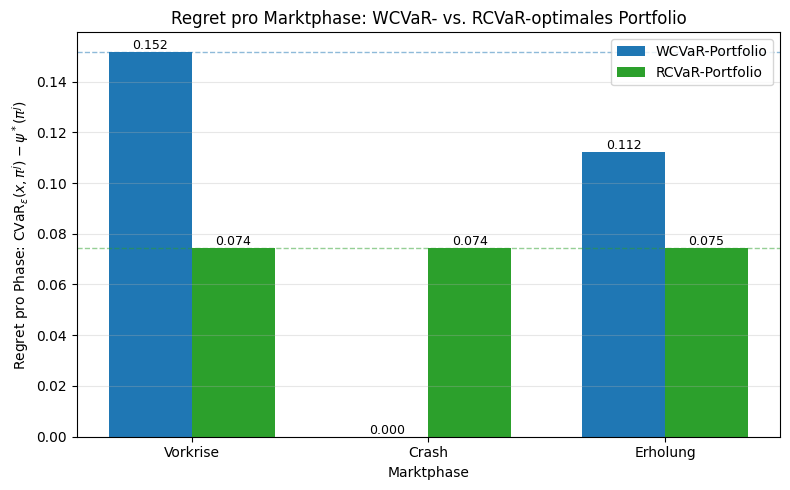

In [33]:
# Werte aus dem Regret-Vergleich (target_mu = -1.60)
phases = ['Vorkrise', 'Crash', 'Erholung']
# Werte aus Abschnitt 5 
cvar_wc = [1.8451, 4.8909, 1.6060]   
cvar_rc = [1.7677, 4.9654, 1.5683]   
psi     = [1.6933, 4.8909, 1.4938]   # Benchmark 

# Regret = CVaR - psi* 
regret_wc = [c - p for c, p in zip(cvar_wc, psi)]
regret_rc = [c - p for c, p in zip(cvar_rc, psi)]

x_pos = np.arange(len(phases))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
bars_wc = ax.bar(x_pos - width/2, regret_wc, width,
                 label='WCVaR-Portfolio', color='tab:blue')
bars_rc = ax.bar(x_pos + width/2, regret_rc, width,
                 label='RCVaR-Portfolio', color='tab:green')

ax.axhline(max(regret_wc), ls='--', color='tab:blue', alpha=0.5, linewidth=1)
ax.axhline(max(regret_rc), ls='--', color='tab:green', alpha=0.5, linewidth=1)

ax.set_xticks(x_pos)
ax.set_xticklabels(phases)
ax.set_xlabel('Marktphase')
ax.set_ylabel(r'Regret pro Phase: $\mathrm{CVaR}_\epsilon(x,\pi^j) - \psi^*(\pi^j)$')
ax.set_title('Regret pro Marktphase: WCVaR- vs. RCVaR-optimales Portfolio')
ax.legend()
ax.grid(axis='y', alpha=0.3)


for bar in list(bars_wc) + list(bars_rc):
    h = bar.get_height()
    ax.annotate(f'{h:.3f}',
                xy=(bar.get_x() + bar.get_width()/2, h),
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig("regret_pro_phase.png", dpi=150)
plt.show()